**import block**

In [1]:
import mne 
mne.set_log_level('WARNING')
#makes it so that you don't have to deal with all of the verbose outputs. 

import scipy 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#can run this in order to stop the verbose outputs from MNE
#mne.set_log_level('WARNING')


In [2]:
import h5py
import numpy as np
import mne

DATA_PATH = '/Users/alexanderspeer/Desktop/eeg-data/lab2-artifact-detection/eeg-data/Exp1_Monopolar_Fz-FC1-FC2-Pz_6x30s_fs256.mat'

# 1. LOAD
with h5py.File(DATA_PATH, 'r') as file:
    eeg = file['y'][:]

if eeg.shape[0] > eeg.shape[1]:
    eeg = eeg.T

#time and sampling rate

time = eeg[0]
fs = int((1 / ((np.mean(np.diff(time))))))
#print(fs)

#creating an info object in MNE
channel_names = ['Fz', 'FC1', 'FC2', 'Pz']

info = mne.create_info(
    ch_names = channel_names,
    sfreq = fs,
    ch_types = 'eeg',
    verbose=False
)

#create a raw object now
raw = mne.io.RawArray(eeg[1:], info, verbose=False)

# crop FIRST to remove the giant artifacts
raw.crop(tmin=10, tmax=170, verbose=False)


# now winsor on clean data
data = raw.get_data()
lower = np.percentile(data, 1)
upper = np.percentile(data, 99)
data = np.clip(data, lower, upper)

# put it back
raw = mne.io.RawArray(data, raw.info) #don't have to do raw.info, just info is fine. 

#add a bandpass and notch
raw.filter(0.5, 40, verbose=False)
raw.notch_filter(60, verbose=False)

#could add verbose=False to make the stuff go away,

#no plotting is going to be done in this cell

<RawArray | 4 x 40961 (160.0 s), ~1.3 MiB, data loaded>

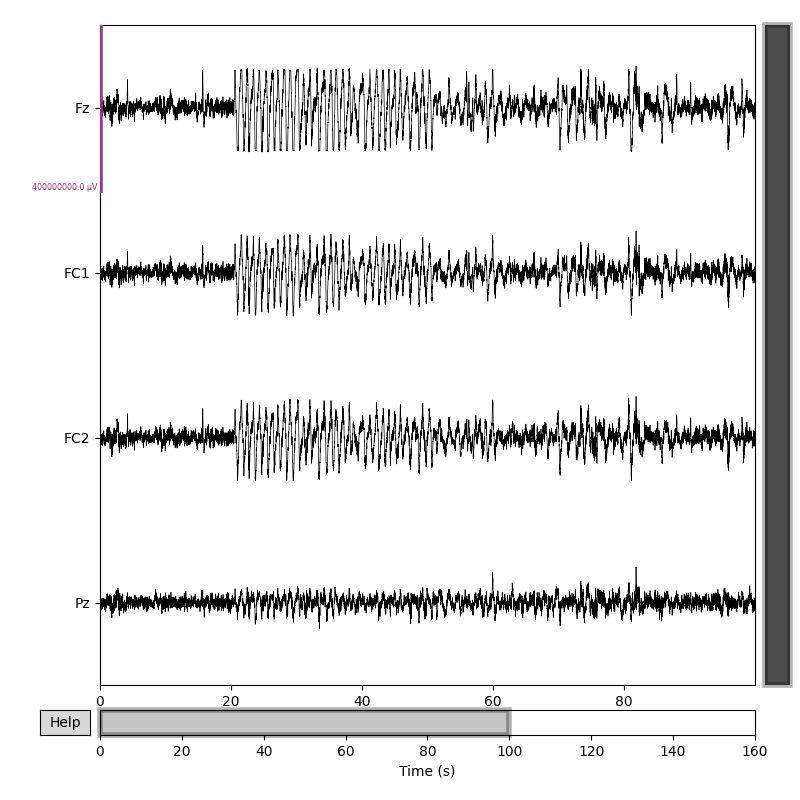

In [ ]:
#make sure that the plotting is being done correctly:

%matplotlib widget
#apparently makes it so that everything renders inside the notebook. 
#I think the normal way that matplotlib works is inline, which is static,
#whereas the widget allows you to interact with the plot while in window. 

mne.viz.set_browser_backend('matplotlib')  # forces raw.plot() to use mpl instead of the Qt app
raw.plot(duration=100, scalings=dict(eeg=200)); #<- THIS IS CRAZY, MATLAB SYNTAX TO SUPRESS THE ADDITIONAL PLOT
#THE SECOND VALUE HERE DICT(EEG=X) IS WHAT SCALES THE AMPLITUDE OF THE WAVEFORM.

#Ipython is looking to visualize or 'print' the last expression in a cell
# adding the semicolon reminds it to skip that. 

**Get a heatmap**

In [ ]:
channel_names = ['Fz', 'FC1', 'FC2', 'Pz']


heatmap = plt.imshow(data, cmap='viridis', aspect='auto')
plt.colorbar(heatmap, label='EEG Amplitude (µV)')
plt.xlabel('Time')
plt.ylabel('Channel')
plt.title('EEG Heatmap')
plt.yticks(ticks=range(len(channel_names)), labels=channel_names)
plt.show()

**3d heatmap for source localization and understanding spatial and temporal dynamics**

In [ ]:
channel_names = ['Fz', 'FC1', 'FC2', 'Pz']
data_ds = data[:, ::10]  # downsample every 10th sample

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for ch_idx in range(data_ds.shape[0]):
    x = np.arange(data_ds.shape[1])
    y = np.full(data_ds.shape[1], ch_idx)
    z = data_ds[ch_idx, :]
    ax.plot(x, y, z)

ax.set_xlabel('Sample Index')
ax.set_ylabel('Channel')
ax.set_zlabel('EEG (V)')
ax.set_yticks(np.arange(len(channel_names)))
ax.set_yticklabels(channel_names)
plt.show()

**Correlation Matrix**

In [ ]:
plt.matshow(np.corrcoef(data))
plt.colorbar()
plt.xticks(range(len(channel_names)), channel_names)
plt.yticks(range(len(channel_names)), channel_names)
plt.title('EEG Channel Correlations')
plt.show()

For this recording, that would make sense, since all of the artifact conditions in the lab instructions were things that would primarily show up on in the fronal lobes.

**experimenting with mne**
essentially loading locs file for topoplots later on

In [ ]:
mne.channels.read_custom_montage('../BCI.locs')

montage = mne.channels.read_custom_montage('../BCI.locs', verbose=None)

raw.set_montage(montage, on_missing='ignore', verbose=None)

# then use raw.info everywhere
values = np.var(data, axis=1)


#amplitude peak to peak
#values = np.max(data, axis=1) - np.min(data, axis=1)

fig, ax = plt.subplots()
mne.viz.plot_topomap(values, raw.info, axes=ax, show=True)

#that is recommended.
#if you have a BCI.locs file, that is how you should load it. 

from the data, you can see that the front electrodes are the ones that contribute the most noise

In [ ]:
#other topoplot that has time bins now:

'''
30 x 6 = 180
time take
nvm apparently I never did a time mask to ax winsoring
'''

#okay now make a bin for every condition on the 30 second mark

durations = [20, 30, 30, 30, 30, 20]  # seconds per condition
conditions = ['Silent', 'Blinking', 'Eye Rolling', 'Chewing', 'Neck Tension', 'Touching Electrodes']

starts = np.cumsum([0] + [d * fs for d in durations[:-1]])
ends = starts + np.array([d * fs for d in durations])

condition_data = [data[:, s:e] for s, e in zip(starts, ends)]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))

for ax, cond_data, cond_name in zip(axes, condition_data, conditions):
    values = np.var(cond_data, axis=1)
    mne.viz.plot_topomap(values, raw.info, axes=ax, show=False)
    ax.set_title(cond_name)

plt.suptitle('Variance per Condition')
plt.tight_layout()
plt.show()

**things that I should know how to do**

-how to make those cool interactive images by extracting the data from the raw() item

-how to go through the whole EEG preprocessing pipeline

-dc drift

--run through everything in mne then go to numpy and sort of understand how everything works. 

-ideally some way to be able to tell where the start-up effects are, and then make the time mask from there

In [ ]:
montage = mne.channels.read_custom_montage('../BCI.locs')
print(montage)
print(montage.ch_names)
